In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# CatBoost

In [2]:
blocks = gpd.read_parquet('../data/traning_data/blocks_with_land_value_class.parquet')
blocks["land_use"] = blocks["land_use"].replace(
    [None, "None", "none", "NaN", "nan", "NULL", "null", ""],
    pd.NA
)
blocks = blocks[blocks["land_use"].notna()].copy()


blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,area_accessibility,land_value_per_sqm,log_land_value,log_land_value_per_sqm,land_value_class_soft_0,land_value_class_soft_1,land_value_class_soft_2,land_value_class_soft_3,land_value_class_pred,land_value_class_soft_expected
0,"POLYGON ((352083.617 6633950.146, 352240.448 6...",0.099000,0.0,0.079912,0.000000,0.401072,0.0,0.417018,AGRICULTURE,0.417018,...,113.847998,942.386203,18.676889,6.849476,0.141792,0.440618,0.350797,0.066793,1,1.342591
1,"POLYGON ((346700.642 6618453.176, 346681.107 6...",1.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,1.000000,...,145.884534,1952.414484,19.040968,7.577334,0.012638,0.107291,0.826455,0.053615,2,1.921047
2,"POLYGON ((347043.363 6618261.219, 347042.608 6...",0.729125,0.0,0.270875,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,0.729125,...,148.543184,1507.223306,19.061421,7.318688,0.023362,0.107805,0.776600,0.092233,2,1.937704
3,"POLYGON ((354879.039 6618859.116, 354845.405 6...",0.454375,0.0,0.000000,0.000000,0.144935,0.0,0.399984,RESIDENTIAL,0.454375,...,132.691062,2197.747147,19.737919,7.695643,0.010342,0.200107,0.548507,0.241044,2,2.020252
4,"POLYGON ((347215.933 6646341.789, 347245.429 6...",0.108707,0.0,0.000000,0.767131,0.057528,0.0,0.000000,INDUSTRIAL,0.767131,...,99.160727,8603.688296,17.843517,9.060062,0.512695,0.456094,0.029580,0.001631,0,0.520147


In [3]:
blocks_with_large_errors = gpd.read_file("../data/traning_data/blocks_with_large_errors.geojson")
blocks_with_large_errors.head()   

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,lag2000_land_value_class_soft_expected,lag3000_land_value_class_soft_expected,n_neighbors_300,n_neighbors_500,n_neighbors_1000,n_neighbors_2000,n_neighbors_3000,land_value_pred,error_pct,geometry
0,0.0,0.000000,0.589514,0.0,0.000000,0.0,0.0,RECREATION,0.589514,0.000000,...,1.597935,1.351681,2,3,7,49,189,1.125203e+07,69503.130660,"POLYGON ((351332.407 6622228.557, 351334.384 6..."
1,0.0,0.000000,0.831374,0.0,0.000000,0.0,0.0,RECREATION,0.831374,0.000000,...,1.571028,1.364549,2,3,6,52,194,-7.112523e+06,2631.321113,"POLYGON ((351359.34 6622283.938, 351359.063 66..."
2,0.0,0.000000,0.882659,0.0,0.032277,0.0,0.0,RECREATION,0.882659,346.178070,...,0.999109,0.904263,0,0,3,85,214,-4.235730e+06,101.046801,"POLYGON ((331955.269 6661845.023, 331965.597 6..."
3,0.0,0.000411,0.897655,0.0,0.075606,0.0,0.0,RECREATION,0.897655,263.206093,...,1.835301,1.924933,1,4,14,76,172,3.671398e+07,2543.486845,"POLYGON ((347948.986 6659533.205, 347951.178 6..."
4,0.0,0.000188,0.999812,0.0,0.000000,0.0,0.0,RECREATION,0.999812,45.826443,...,1.025847,1.037357,0,0,4,34,133,7.808158e+08,262.268156,"POLYGON ((333059.258 6662638.042, 333088.351 6..."


In [4]:
blocks_with_error_over_60pct = gpd.read_file("../data/traning_data/blocks_with_error_over_60pct.geojson")
blocks_with_error_over_60pct.head()   

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,n_neighbors_300,n_neighbors_500,n_neighbors_1000,n_neighbors_2000,n_neighbors_3000,pred_raw,land_value_pred,land_value_true,error_pct,geometry
0,0.000000,0.0,0.984579,0.0,0.000000,0.0,0.0,RECREATION,0.984579,585.487192,...,0,0,1,39,89,8.889784e+08,8.889784e+08,5.277053e+08,68.461149,"POLYGON ((339406.964 6666833.267, 339707.167 6..."
1,0.568247,0.0,0.288528,0.0,0.098242,0.0,0.0,RESIDENTIAL,0.568247,513.484777,...,1,3,9,44,68,5.687361e+07,5.687361e+07,3.369187e+07,68.805126,"POLYGON ((358575.218 6656798.193, 358572.41 66..."
2,0.000000,0.0,1.000000,0.0,0.000000,0.0,0.0,RECREATION,1.000000,475.554096,...,0,2,2,8,26,3.062602e+07,3.062602e+07,1.697712e+07,80.395863,"POLYGON ((334862.496 6663817.793, 334815.862 6..."
3,0.979315,0.0,0.000178,0.0,0.020507,0.0,0.0,RESIDENTIAL,0.979315,8696.240991,...,4,13,36,118,270,2.730839e+08,2.730839e+08,9.553385e+07,185.850442,"POLYGON ((347717.715 6643080.484, 347706.163 6..."
4,0.966722,0.0,0.000000,0.0,0.033278,0.0,0.0,RESIDENTIAL,0.966722,7423.965448,...,8,16,46,206,469,1.967152e+08,1.967152e+08,1.029906e+08,91.003089,"POLYGON ((351835.318 6645352.122, 351815.764 6..."


In [5]:
blocks_with_error_over_60pct2 = gpd.read_file("../data/traning_data/blocks_with_error_over_60pct2.geojson")
blocks_with_error_over_60pct2.head()   

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,n_neighbors_300,n_neighbors_500,n_neighbors_1000,n_neighbors_2000,n_neighbors_3000,pred_raw,land_value_pred,land_value_true,error_pct,geometry
0,0.036769,0.049478,0.611127,0.0,0.301941,0.0,0.0,RECREATION,0.611127,225.914856,...,2,4,34,116,141,2.905371e+07,2.905371e+07,2.886810e+06,906.429650,"POLYGON ((331486.283 6665886.568, 331508.047 6..."
1,0.000000,0.000000,0.024514,0.0,0.975486,0.0,0.0,TRANSPORT,0.975486,0.000000,...,4,8,25,72,107,-9.688092e+05,-9.688092e+05,8.390276e+06,111.546810,"POLYGON ((330535.234 6667657.909, 330535.234 6..."
2,0.326325,0.000000,0.163653,0.0,0.498151,0.0,0.0,TRANSPORT,0.498151,2015.949680,...,3,9,27,53,84,1.458278e+08,1.458278e+08,8.995611e+07,62.109940,"POLYGON ((365623.978 6631240.154, 365626.905 6..."
3,0.844613,0.000000,0.036136,0.0,0.119251,0.0,0.0,RESIDENTIAL,0.844613,5335.847961,...,6,12,32,82,116,5.582991e+07,5.582991e+07,3.405182e+07,63.955737,"POLYGON ((365815.82 6625870.365, 365803.179 66..."
4,0.000000,0.000000,0.895150,0.0,0.104850,0.0,0.0,RECREATION,0.895150,0.000000,...,9,16,61,213,473,1.572839e+07,1.572839e+07,4.482206e+06,250.907204,"POLYGON ((351385.713 6647342.1, 351343.655 664..."


In [6]:
blocks_with_error_over_60pct3 = gpd.read_file("../data/traning_data/blocks_with_error_over_60pct3.geojson")
blocks_with_error_over_60pct3.head()   

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,n_neighbors_300,n_neighbors_500,n_neighbors_1000,n_neighbors_2000,n_neighbors_3000,pred_raw,land_value_pred,land_value_true,error_pct,geometry
0,0.108342,0.000000,0.891658,0.0,0.000000,0.0,0.0,RECREATION,0.891658,0.000000,...,5,14,60,205,447,5.678058e+07,5.678058e+07,1.786907e+07,217.758932,"POLYGON ((351428.245 6647300.266, 351440.055 6..."
1,0.024715,0.072627,0.489266,0.0,0.413393,0.0,0.0,RECREATION,0.489266,161.467098,...,10,21,74,248,427,6.659308e+06,6.659308e+06,2.074318e+07,67.896405,"POLYGON ((348997.996 6646368.274, 348999.869 6..."
2,0.226151,0.590566,0.132126,0.0,0.051156,0.0,0.0,BUSINESS,0.590566,32311.556107,...,4,10,43,181,434,5.592216e+08,5.592216e+08,3.421804e+08,63.428892,"POLYGON ((351482.192 6648261.957, 351499.765 6..."
3,0.999419,0.000581,0.000000,0.0,0.000000,0.0,0.0,RESIDENTIAL,0.999419,8227.586617,...,3,9,33,82,185,2.868954e+08,2.868954e+08,1.712276e+08,67.552047,"POLYGON ((347126.83 6643214.39, 347135.632 664..."
4,0.763586,0.000000,0.000000,0.0,0.236414,0.0,0.0,RESIDENTIAL,0.763586,4099.369141,...,4,15,52,154,291,1.421954e+08,1.421954e+08,8.546343e+07,66.381611,"POLYGON ((353573.678 6646818.066, 353573.235 6..."


In [7]:
# старт
blocks_clean = blocks.copy()

# 1) удалить blocks_with_large_errors
tmp = blocks_with_large_errors
if blocks_clean.crs != tmp.crs:
    tmp = tmp.to_crs(blocks_clean.crs)
bad_geom = set(tmp.geometry.to_wkb())
blocks_clean = blocks_clean.loc[~blocks_clean.geometry.to_wkb().isin(bad_geom)].copy()

# 2) удалить blocks_with_error_over_60pct
tmp = blocks_with_error_over_60pct
if blocks_clean.crs != tmp.crs:
    tmp = tmp.to_crs(blocks_clean.crs)
bad_geom = set(tmp.geometry.to_wkb())
blocks_clean = blocks_clean.loc[~blocks_clean.geometry.to_wkb().isin(bad_geom)].copy()

# # 3) удалить blocks_with_error_over_60pct2
# tmp = blocks_with_error_over_60pct2
# if blocks_clean.crs != tmp.crs:
#     tmp = tmp.to_crs(blocks_clean.crs)
# bad_geom = set(tmp.geometry.to_wkb())
# blocks_clean = blocks_clean.loc[~blocks_clean.geometry.to_wkb().isin(bad_geom)].copy()

# # 4) удалить blocks_with_error_over_60pct3
# tmp = blocks_with_error_over_60pct3
# if blocks_clean.crs != tmp.crs:
#     tmp = tmp.to_crs(blocks_clean.crs)
# bad_geom = set(tmp.geometry.to_wkb())
# blocks_clean = blocks_clean.loc[~blocks_clean.geometry.to_wkb().isin(bad_geom)].copy()

blocks_clean.head()



,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,area_accessibility,land_value_per_sqm,log_land_value,log_land_value_per_sqm,land_value_class_soft_0,land_value_class_soft_1,land_value_class_soft_2,land_value_class_soft_3,land_value_class_pred,land_value_class_soft_expected
0,"POLYGON ((352083.617 6633950.146, 352240.448 6...",0.099000,0.0,0.079912,0.000000,0.401072,0.0,0.417018,AGRICULTURE,0.417018,...,113.847998,942.386203,18.676889,6.849476,0.141792,0.440618,0.350797,0.066793,1,1.342591
1,"POLYGON ((346700.642 6618453.176, 346681.107 6...",1.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,1.000000,...,145.884534,1952.414484,19.040968,7.577334,0.012638,0.107291,0.826455,0.053615,2,1.921047
2,"POLYGON ((347043.363 6618261.219, 347042.608 6...",0.729125,0.0,0.270875,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,0.729125,...,148.543184,1507.223306,19.061421,7.318688,0.023362,0.107805,0.776600,0.092233,2,1.937704
3,"POLYGON ((354879.039 6618859.116, 354845.405 6...",0.454375,0.0,0.000000,0.000000,0.144935,0.0,0.399984,RESIDENTIAL,0.454375,...,132.691062,2197.747147,19.737919,7.695643,0.010342,0.200107,0.548507,0.241044,2,2.020252
4,"POLYGON ((347215.933 6646341.789, 347245.429 6...",0.108707,0.0,0.000000,0.767131,0.057528,0.0,0.000000,INDUSTRIAL,0.767131,...,99.160727,8603.688296,17.843517,9.060062,0.512695,0.456094,0.029580,0.001631,0,0.520147


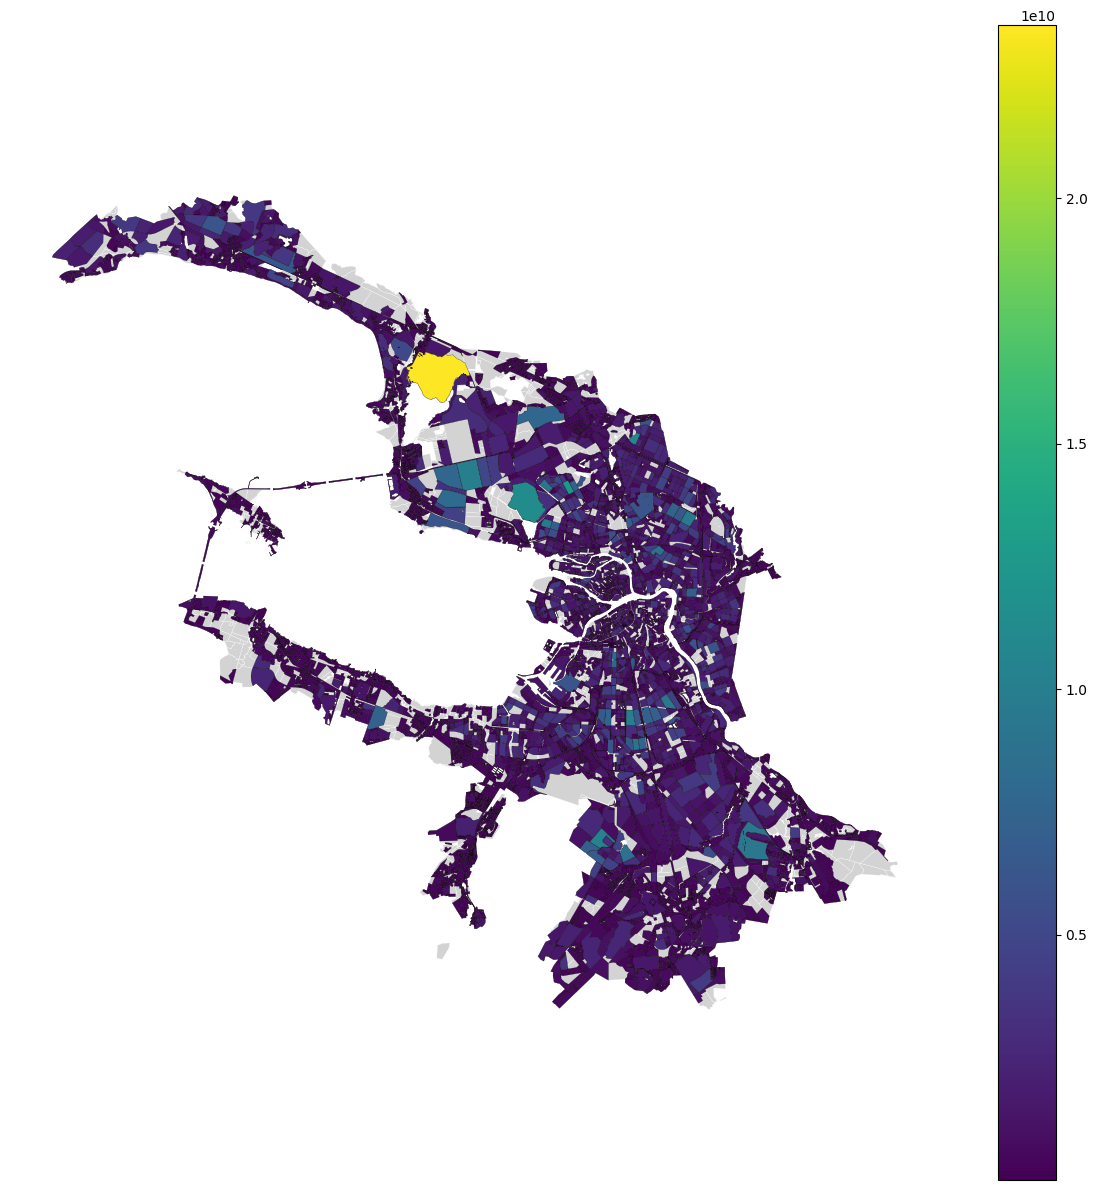

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 15))

# Все кварталы серым фоном
blocks.plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.2)

# Отфильтрованные поверх с раскраской по land_value_per_sqm
blocks_clean.plot(
    ax=ax,
    column="land_value",
    cmap="viridis",
    legend=True,
    edgecolor="black",
    linewidth=0.2
)

ax.axis("off")
plt.show()

In [9]:
import pandas as pd

col = "land_use"

# Кол-во по land_use в blocks
cnt_blocks = (
    blocks[col]
    .value_counts(dropna=False)
    .rename("count_blocks")
)

# Кол-во по land_use в blocks_clean
cnt_blocks_clean = (
    blocks_clean[col]
    .value_counts(dropna=False)
    .rename("count_blocks_clean")
)

# Объединяем в одну таблицу
land_use_counts = (
    pd.concat([cnt_blocks, cnt_blocks_clean], axis=1)
    .fillna(0)
    .astype(int)
    .reset_index()
    .rename(columns={"index": col})
    .sort_values(col, na_position="last")
)

display(land_use_counts)


,land_use,count_blocks,count_blocks_clean
5,AGRICULTURE,142,119
4,BUSINESS,309,270
3,INDUSTRIAL,501,447
1,RECREATION,1671,1065
0,RESIDENTIAL,4919,4207
6,SPECIAL,126,102
2,TRANSPORT,1049,807


land_value_per_sqm                1.000000
log_land_value_per_sqm            0.844781
fsi                               0.713207
gsi                               0.617828
l                                 0.505152
log_land_value                    0.432739
share_non_living                  0.423357
share_living                      0.420705
land_value_class_soft_expected    0.355501
land_value_class_pred             0.350929
land_value_class_soft_3           0.341509
residential                       0.332306
land_value                        0.322447
living_area                       0.277582
build_floor_area                  0.267988
population                        0.220575
mxi                               0.207792
non_living_area                   0.205123
footprint_area                    0.119331
land_value_class_soft_2           0.024308
business                          0.002532
share                            -0.038709
osr                              -0.043046
special    

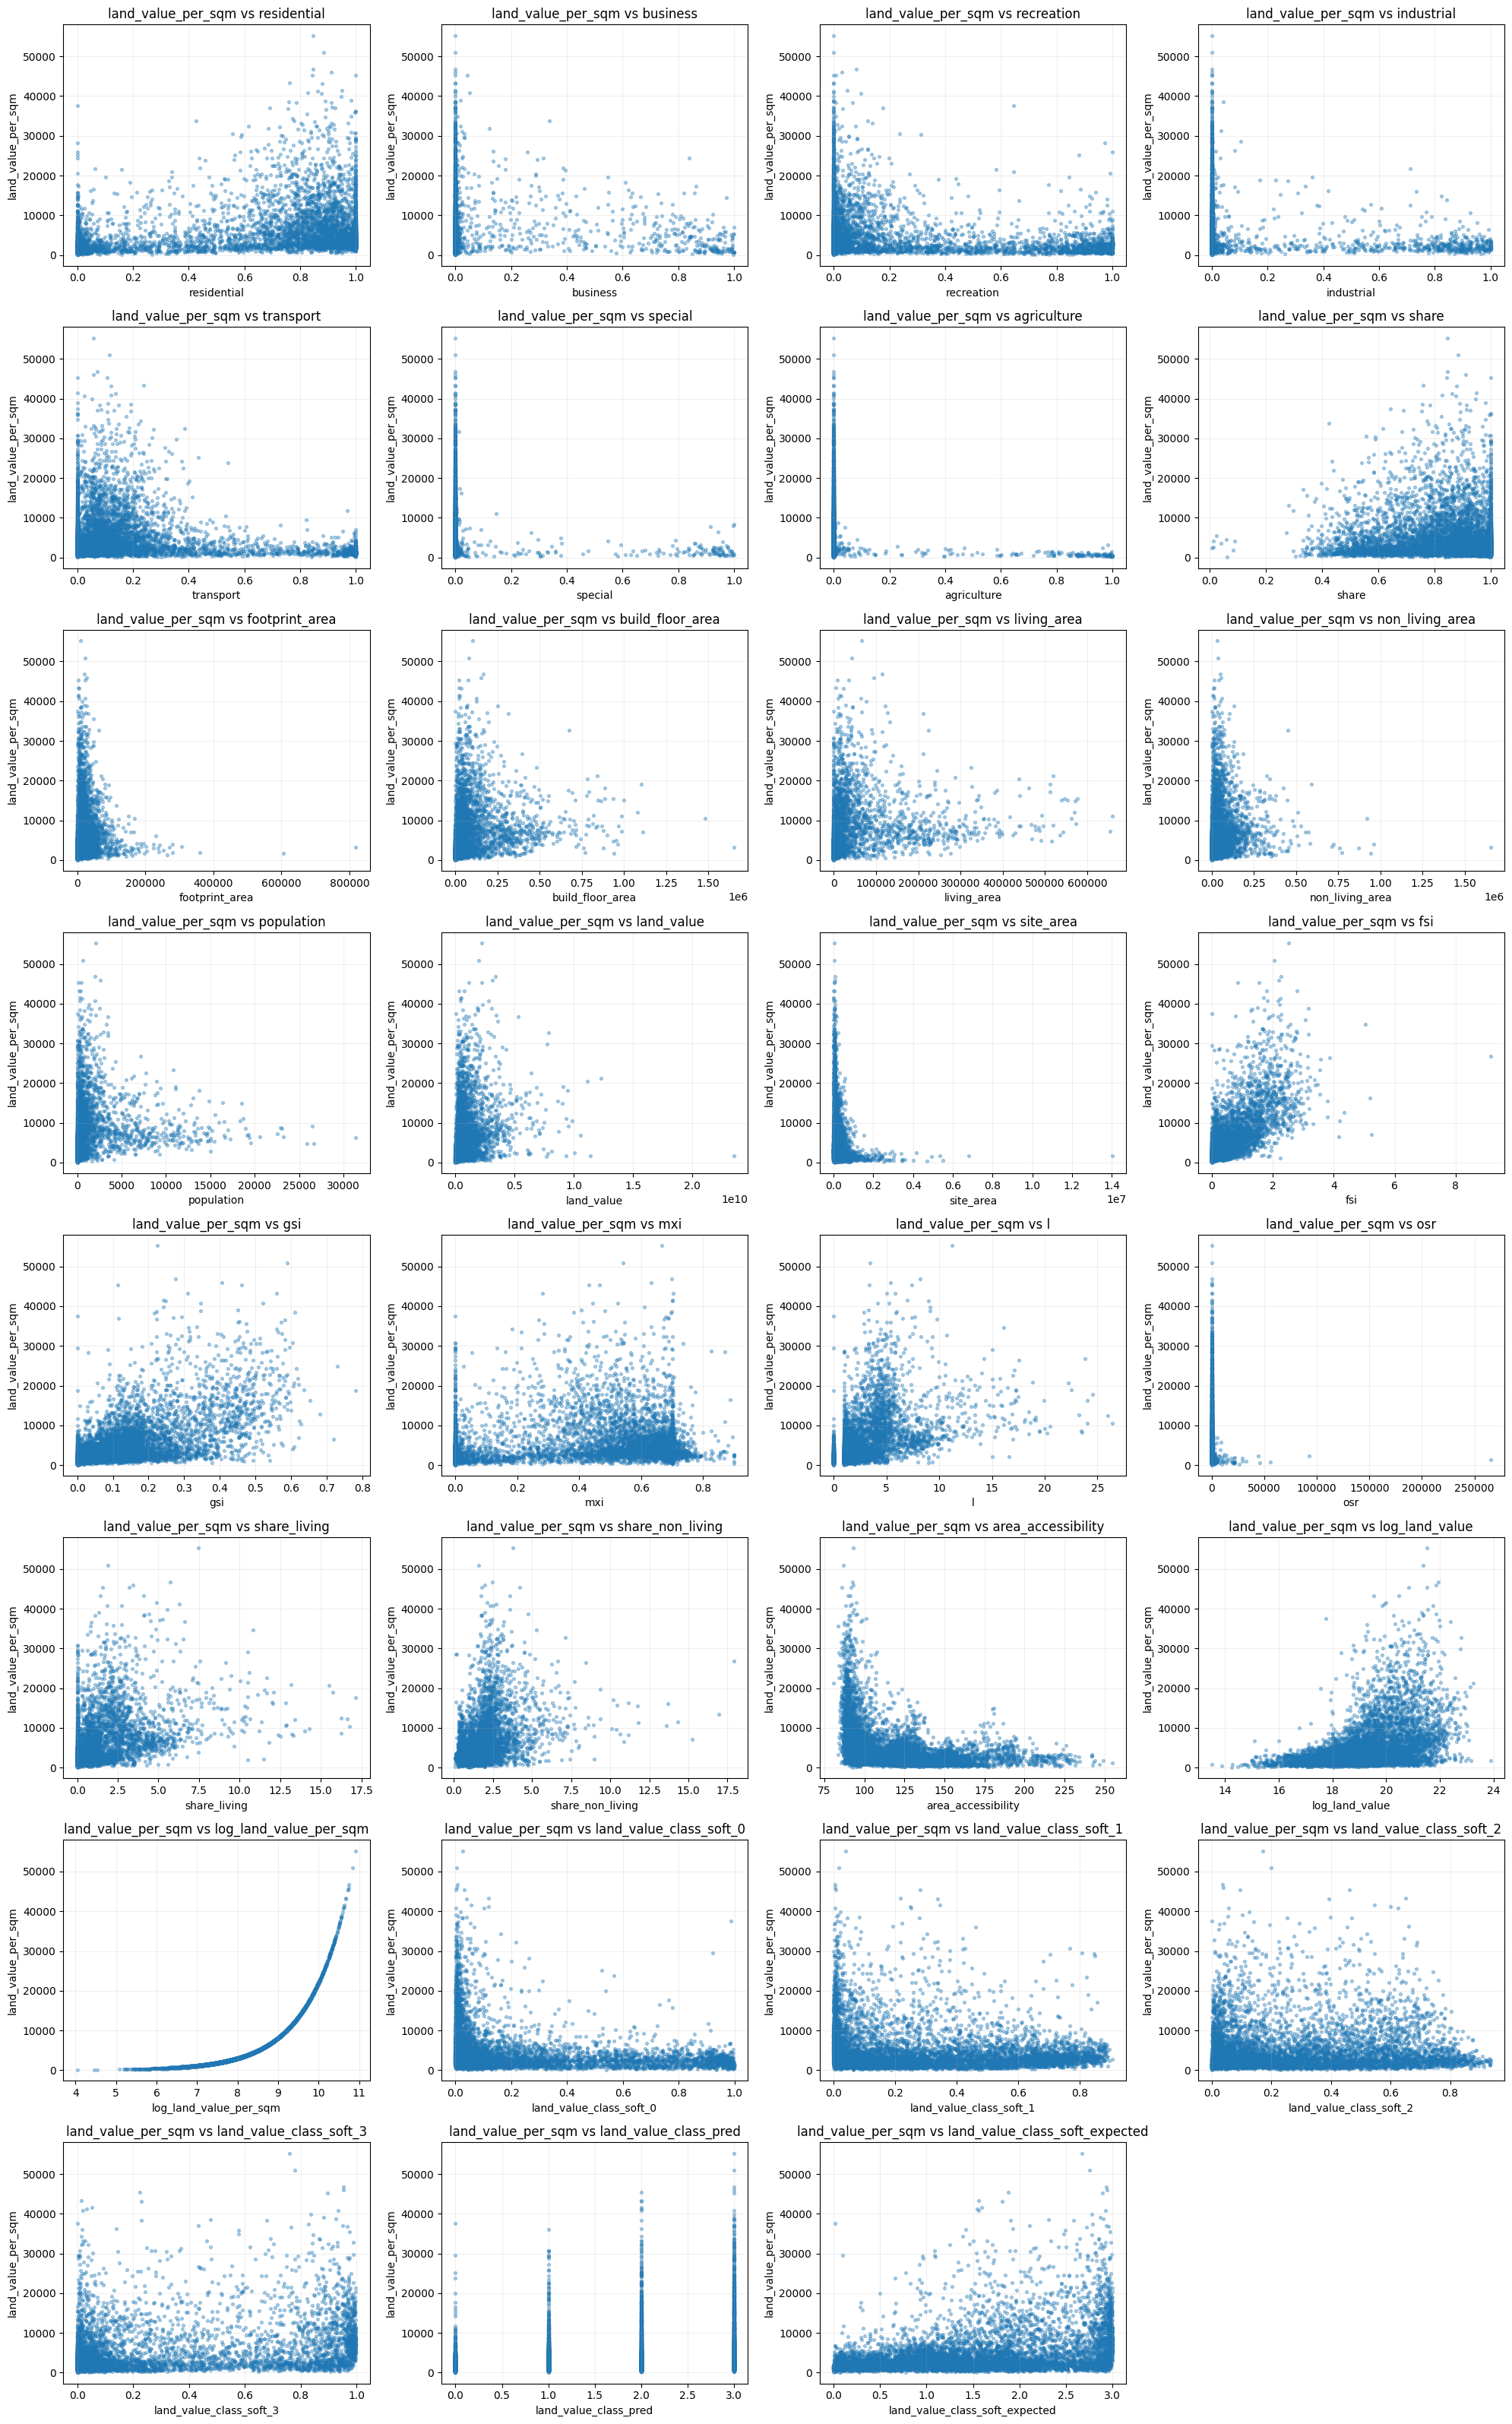

In [10]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

target_col = "land_value_per_sqm"
num_cols = [c for c in blocks_clean.columns if pd.api.types.is_numeric_dtype(blocks_clean[c])]
corr_to_target = (
    blocks_clean[num_cols]
    .corr(method="pearson")[target_col]
    .dropna()
    .sort_values(ascending=False)
)
display(corr_to_target)

# Целевая переменная
target_col = "land_value_per_sqm"

# Берем все фичи кроме target и geometry
exclude = {target_col, "geometry"}
feature_cols = [c for c in blocks_clean.columns if c not in exclude]

# Числовые фичи для scatter
num_features = [
    c for c in feature_cols
    if pd.api.types.is_numeric_dtype(blocks_clean[c])
]

# Подготовка
n = len(num_features)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)
axes = axes.flatten()

for i, col in enumerate(num_features):
    tmp = blocks_clean[[col, target_col]].dropna()
    axes[i].scatter(tmp[col], tmp[target_col], s=8, alpha=0.35)
    axes[i].set_title(f"{target_col} vs {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target_col)
    axes[i].grid(alpha=0.2)

# Удаляем пустые оси
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) выбери колонку цены (подставь свою)
col = "land_value" 

s = pd.to_numeric(blocks_clean[col], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()

print("N:", len(s))
print("Mean:", s.mean())
print("Std:", s.std())
print("CV (std/mean):", s.std() / s.mean())
print("IQR:", s.quantile(0.75) - s.quantile(0.25))
print("Quantiles:\n", s.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))


N: 7017
Mean: 552761692.487894
Std: 1009193977.5635258
CV (std/mean): 1.8257306743188033
IQR: 496505265.6570754
Quantiles:
 0.01    7.145619e+06
0.05    2.294435e+07
0.25    7.893674e+07
0.50    2.005307e+08
0.75    5.754420e+08
0.95    2.267967e+09
0.99    4.657303e+09
Name: land_value, dtype: float64


# Тестовое обучение модели на всех данных (без фолдов). Цель - убедиться, что модель обучается и выдаёт адекватные метрики.

In [12]:
blocks_clean.columns.to_list()

['geometry',
 'residential',
 'business',
 'recreation',
 'industrial',
 'transport',
 'special',
 'agriculture',
 'land_use',
 'share',
 'footprint_area',
 'build_floor_area',
 'living_area',
 'non_living_area',
 'population',
 'land_value',
 'site_area',
 'fsi',
 'gsi',
 'mxi',
 'l',
 'osr',
 'share_living',
 'share_non_living',
 'morphotype',
 'area_accessibility',
 'land_value_per_sqm',
 'log_land_value',
 'log_land_value_per_sqm',
 'land_value_class_soft_0',
 'land_value_class_soft_1',
 'land_value_class_soft_2',
 'land_value_class_soft_3',
 'land_value_class_pred',
 'land_value_class_soft_expected']

In [13]:
# === EconML: effect of treatment_col on land_value_per_sqm ===
# pip install econml

import numpy as np
import pandas as pd

from catboost import CatBoostRegressor
from econml.dml import LinearDML

from urbanomy.methods.land_value_modeling.training_utils import (
    build_radii_weights,
    add_lags_full_df,
    feature_names,
)

# 1) Настройки
target_col = "land_value_per_sqm"
treatment_col = "area_accessibility"   # <- меняй здесь: "fsi", "gsi", "l", etc.
radius_list = [300, 500, 1000, 2000, 3000]
seed = 42
use_services = False

exclude_base = {
    "geometry",
    "land_value",
    "land_value_per_sqm",
    "log_land_value_per_sqm",
    "log_land_value",
    "osr",
    "share_non_living",
    "share_living",
    "land_value_class_soft_expected",
    "district_name",
}

cat_features = [c for c in ["land_use", "morphotype"] if c in blocks_clean.columns]

def is_service_col(col: str) -> bool:
    return col.lower().startswith("count_")

# 2) Базовые признаки
feature_cols = []
for c in blocks_clean.columns:
    if c in exclude_base:
        continue
    if (not use_services) and is_service_col(c):
        continue
    feature_cols.append(c)

if treatment_col not in blocks_clean.columns:
    raise ValueError(f"treatment_col '{treatment_col}' not found in blocks_clean")

# treatment не должен входить в X
feature_cols_for_x = [c for c in feature_cols if c != treatment_col]

# 3) Подготовка данных + lag-фичи
data_df = blocks_clean.copy()

for c in cat_features:
    if c in data_df.columns:
        data_df[c] = data_df[c].astype("string").fillna("missing")

numeric_feats = [
    c for c in feature_cols
    if c not in cat_features and c != target_col and c in data_df.columns
]

weights = build_radii_weights(data_df, radius_list)
data_lag = add_lags_full_df(data_df, weights=weights, numeric_cols=numeric_feats)

base_cols_for_model = list(
    dict.fromkeys([c for c in feature_cols_for_x if c in data_lag.columns] + cat_features)
)
x_feats = feature_names(data_lag, base_cols_for_model, target_col)

# 4) Формируем Y, T, X
Y = pd.to_numeric(data_lag[target_col], errors="coerce")
T = pd.to_numeric(data_lag[treatment_col], errors="coerce")
X = data_lag[x_feats].copy()

# Все категориальные -> dummy, затем всё -> float
X = pd.get_dummies(X, dummy_na=True)
X = X.apply(pd.to_numeric, errors="coerce").astype(float)
Y = pd.to_numeric(Y, errors="coerce").astype(float)
T = pd.to_numeric(T, errors="coerce").astype(float)

mask = (
    np.isfinite(Y.to_numpy()) &
    np.isfinite(T.to_numpy()) &
    np.all(np.isfinite(X.to_numpy(dtype=float)), axis=1)
)

Y_np = Y.to_numpy()[mask]
T_np = T.to_numpy()[mask]
X_df = X.loc[mask].copy()
data_effect = data_lag.loc[mask].copy()

print("Rows used:", len(X_df))
print("Treatment:", treatment_col)
print("X shape:", X_df.shape)

# 5) Внутренние модели EconML
# Обе на MAE, как ты просил
model_y = CatBoostRegressor(
    loss_function="MAE",
    eval_metric="MAE",
    iterations=20000,
    od_wait=500,
    depth=6,
    learning_rate=0.03,
    verbose=0,
    random_seed=seed,
)

model_t = CatBoostRegressor(
    loss_function="MAE",
    eval_metric="MAE",
    iterations=20000,
    od_wait=500,
    depth=6,
    learning_rate=0.03,
    verbose=0,
    random_seed=seed,
)

# 6) Causal model
est = LinearDML(
    model_y=model_y,
    model_t=model_t,
    discrete_treatment=False,   # treatment непрерывный
    random_state=seed,
)

est.fit(Y_np, T_np, X=X_df)

# 7) Эффект по каждому кварталу
te = est.effect(X=X_df)
ate = est.ate(X=X_df)

# доверительный интервал для среднего эффекта
try:
    ate_lb, ate_ub = est.ate_interval(X=X_df)
    print(f"ATE for '{treatment_col}': {ate:.6f}")
    print(f"ATE 95% CI: [{ate_lb:.6f}, {ate_ub:.6f}]")
except Exception:
    print(f"ATE for '{treatment_col}': {ate:.6f}")

result = data_effect.copy()
result["treatment_effect_per_unit"] = te

# 8) Сценарный сдвиг
delta = -5
result[f"delta_price_if_{treatment_col}_plus_{delta}"] = (
    result["treatment_effect_per_unit"] * delta
)

display(
    result[
        [
            treatment_col,
            target_col,
            "treatment_effect_per_unit",
            f"delta_price_if_{treatment_col}_plus_{delta}",
        ]
    ].head(20)
)

print(result["treatment_effect_per_unit"].describe())

# 9) Средний эффект по land_use
if "land_use" in result.columns:
    effect_by_landuse = (
        result.groupby("land_use", dropna=False)
        .agg(
            n=("treatment_effect_per_unit", "size"),
            mean_te=("treatment_effect_per_unit", "mean"),
            median_te=("treatment_effect_per_unit", "median"),
            p90_te=("treatment_effect_per_unit", lambda s: s.quantile(0.90)),
        )
        .sort_values("mean_te", ascending=False)
    )
    display(effect_by_landuse)



Rows used: 7017
Treatment: area_accessibility
X shape: (7017, 169)
ATE for 'area_accessibility': 40.158940
ATE 95% CI: [3.053117, 77.264764]


/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/econml/sklearn_extensions/linear_model.py:1815: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-variance matrix is underdetermined. Inference will be invalid!")


,area_accessibility,land_value_per_sqm,treatment_effect_per_unit,delta_price_if_area_accessibility_plus_-5
0,113.847998,942.386203,19.334550,-96.672750
1,145.884534,1952.414484,62.557464,-312.787322
2,148.543184,1507.223306,52.685411,-263.427053
3,132.691062,2197.747147,143.644349,-718.221744
4,99.160727,8603.688296,46.361893,-231.809463
5,155.318211,1421.128598,16.285481,-81.427405
8,118.807913,1160.558788,29.108827,-145.544134
9,115.546295,3325.537139,-53.989593,269.947963
10,124.055670,1627.563780,4.167435,-20.837176
11,135.219530,631.882251,-16.898271,84.491356


count    7017.000000
mean       40.158940
std       148.366550
min     -1332.184057
25%       -37.819062
50%        13.766914
75%        87.312309
max      1556.541853
Name: treatment_effect_per_unit, dtype: float64


,n,mean_te,median_te,p90_te
land_use,,,,
RESIDENTIAL,4207,58.833131,17.091283,273.325887
BUSINESS,270,30.543656,34.547886,185.156036
RECREATION,1065,26.850130,18.113348,146.793187
SPECIAL,102,12.371579,1.681898,113.385801
TRANSPORT,807,5.317753,4.597472,129.175001
INDUSTRIAL,447,-12.545106,-8.281464,104.044407
AGRICULTURE,119,-21.038133,-24.292315,74.511937


In [ ]:
# # === Scenario simulation with _repair_genome ===

# import numpy as np
# import pandas as pd
# from catboost import Pool
# from tqdm.auto import tqdm

# from urbanomy.methods.land_value_modeling import ScenarioTEPModifier
# from urbanomy.methods.land_value_modeling.ga_mc_optimizer import DistrictProblem
# from urbanomy.methods.land_value_modeling.training_utils import (
#     prep_cat_inplace,
#     build_radii_weights,
#     add_lags_full_df,
#     feature_names,
#     to_original_scale,
# )

# # ------------------------------------------------------------------
# # 1) Настройки
# # ------------------------------------------------------------------
# target_col = "land_value_per_sqm"
# treatment_col = "l"          # что меняем
# delta = 1.0                  # например +1 этаж
# radius_list = [300, 500, 1000, 2000, 3000]
# use_services = False
# seed = 42

# exclude_base = {
#     "geometry",
#     "land_value",
#     "land_value_per_sqm",
#     "log_land_value_per_sqm",
#     "log_land_value",
#     "osr",
#     "share_non_living",
#     "share_living",
#     "land_value_class_soft_expected",
#     "district_name",
# }

# cat_features = [c for c in ["land_use", "morphotype"] if c in blocks_clean.columns]

# def is_service_col(col: str) -> bool:
#     return col.lower().startswith("count_")

# feature_cols = []
# for c in blocks_clean.columns:
#     if c in exclude_base:
#         continue
#     if (not use_services) and is_service_col(c):
#         continue
#     feature_cols.append(c)

# numeric_feats = [
#     c for c in feature_cols
#     if c not in cat_features and c != target_col and c in blocks_clean.columns
# ]

# land_use_keys = [
#     "residential",
#     "business",
#     "recreation",
#     "industrial",
#     "transport",
#     "special",
#     "agriculture",
# ]

# # ------------------------------------------------------------------
# # 2) Хелпер: подготовить признаки и получить прогноз модели
# # ------------------------------------------------------------------
# def predict_blocks(blocks_df, model):
#     work_df = blocks_df.copy()
#     prep_cat_inplace(work_df, cat_features)

#     weights = build_radii_weights(work_df, radius_list)
#     data_lag = add_lags_full_df(work_df, weights=weights, numeric_cols=numeric_feats)

#     base_cols_for_model = list(dict.fromkeys(list(feature_cols) + list(cat_features)))
#     feats = feature_names(data_lag, base_cols_for_model, target_col)

#     pred_raw = np.asarray(model.predict(data_lag[feats])).reshape(-1)
#     pred = to_original_scale(pred_raw, target_col=target_col)

#     out = data_lag.copy()
#     out["pred_raw"] = pred_raw
#     out[f"{target_col}_pred"] = pred
#     return out, feats

# # ------------------------------------------------------------------
# # 3) Хелпер: собрать базовый genome из текущей строки
# # ------------------------------------------------------------------
# def make_base_genome(row: pd.Series) -> dict:
#     genome = {}

#     for k in land_use_keys:
#         if k in row.index:
#             genome[k] = float(row.get(k, 0.0))

#     for k in [
#         "footprint_area",
#         "l",
#         "mxi",
#         "build_floor_area",
#         "living_area",
#         "non_living_area",
#         "population",
#         "fsi",
#         "gsi",
#         "share",
#         "land_use",
#         "morphotype",
#     ]:
#         if k in row.index:
#             genome[k] = row[k]

#     return genome

# # ------------------------------------------------------------------
# # 4) Хелпер: сделать repair для одного квартала
# # ------------------------------------------------------------------
# def repair_changes_for_block(blocks_df, target_idx, new_treatment_value):
#     # constraints нужны только чтобы у DistrictProblem появились var_names
#     constraints = {
#         "footprint_area": {"type": "float", "min": 0.0, "max": 1.0},
#         "l": {"type": "float", "min": 1.0, "max": 50.0},
#         "mxi": {"type": "float", "min": 0.0, "max": 1.0},
#         "residential": {"type": "float", "min": 0.0, "max": 1.0},
#         "business": {"type": "float", "min": 0.0, "max": 1.0},
#         "recreation": {"type": "float", "min": 0.0, "max": 1.0},
#         "industrial": {"type": "float", "min": 0.0, "max": 1.0},
#         "transport": {"type": "float", "min": 0.0, "max": 1.0},
#         "special": {"type": "float", "min": 0.0, "max": 1.0},
#         "agriculture": {"type": "float", "min": 0.0, "max": 1.0},
#     }

#     problem = DistrictProblem(
#         blocks=blocks_df,
#         model=model,                 # не используется внутри _repair_genome, но нужен конструктору
#         estimator_kwargs={},
#         constraints=constraints,
#         benchmarks={},
#         potential_df=pd.DataFrame(),
#         target_idx=target_idx,
#     )

#     row = blocks_df.loc[target_idx]
#     genome = make_base_genome(row)
#     genome[treatment_col] = new_treatment_value

#     repaired = problem._repair_genome(genome)
#     return repaired

# # ------------------------------------------------------------------
# # 5) Сценарий для одного квартала
# # ------------------------------------------------------------------
# def simulate_block_delta(blocks_df, target_idx, delta):
#     base_row = blocks_df.loc[target_idx]
#     old_value = float(base_row[treatment_col])
#     new_value = old_value + delta

#     repaired = repair_changes_for_block(blocks_df, target_idx, new_value)

#     modifier = ScenarioTEPModifier(blocks_df)
#     blocks_after = modifier.apply(target_idx, repaired)

#     pred_before_df, _ = predict_blocks(blocks_df, model)
#     pred_after_df, _ = predict_blocks(blocks_after, model)

#     before_price = float(pred_before_df.loc[target_idx, f"{target_col}_pred"])
#     after_price = float(pred_after_df.loc[target_idx, f"{target_col}_pred"])

#     result = {
#         "target_idx": target_idx,
#         "old_treatment": old_value,
#         "new_treatment": float(blocks_after.loc[target_idx, treatment_col]),
#         "before_price": before_price,
#         "after_price": after_price,
#         "delta_price": after_price - before_price,
#         "delta_price_pct": ((after_price / before_price) - 1.0) * 100.0 if before_price != 0 else np.nan,
#     }

#     # полезно вернуть и repaired параметры
#     for k in ["footprint_area", "l", "mxi", "fsi", "gsi", "build_floor_area", "living_area", "non_living_area"]:
#         if k in repaired:
#             result[k] = repaired[k]

#     return result, blocks_after

# # ------------------------------------------------------------------
# # 6) Пример: один квартал
# # ------------------------------------------------------------------
# target_idx = blocks_clean.index[0]   # подставь нужный индекс
# one_result, blocks_after_one = simulate_block_delta(blocks_clean, target_idx, delta=1.0)
# display(pd.Series(one_result))

# # ------------------------------------------------------------------
# # 7) Прогон по всем кварталам
# # ------------------------------------------------------------------
# rows = []
# for idx in tqdm(blocks_clean.index, total=len(blocks_clean), desc="Blocks"):
#     try:
#         res, _ = simulate_block_delta(blocks_clean, idx, delta=delta)
#         rows.append(res)
#     except Exception:
#         continue

# scenario_effect_df = pd.DataFrame(rows)

# display(scenario_effect_df.head())
# print(scenario_effect_df["delta_price"].describe())
# print(scenario_effect_df["delta_price_pct"].describe())


target_idx             0.000000
old_treatment          1.000000
new_treatment          2.000000
before_price        1319.518770
after_price         1505.703921
delta_price          186.185151
delta_price_pct       14.110080
footprint_area        69.018103
l                      2.000000
mxi                    0.000000
fsi                    0.001007
gsi                    0.000503
build_floor_area     138.036205
living_area            0.000000
non_living_area      138.036205
dtype: float64

Blocks:   0%|          | 0/7017 [00:00<?, ?it/s]

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x105825720>>
Traceback (most recent call last):
  File "/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


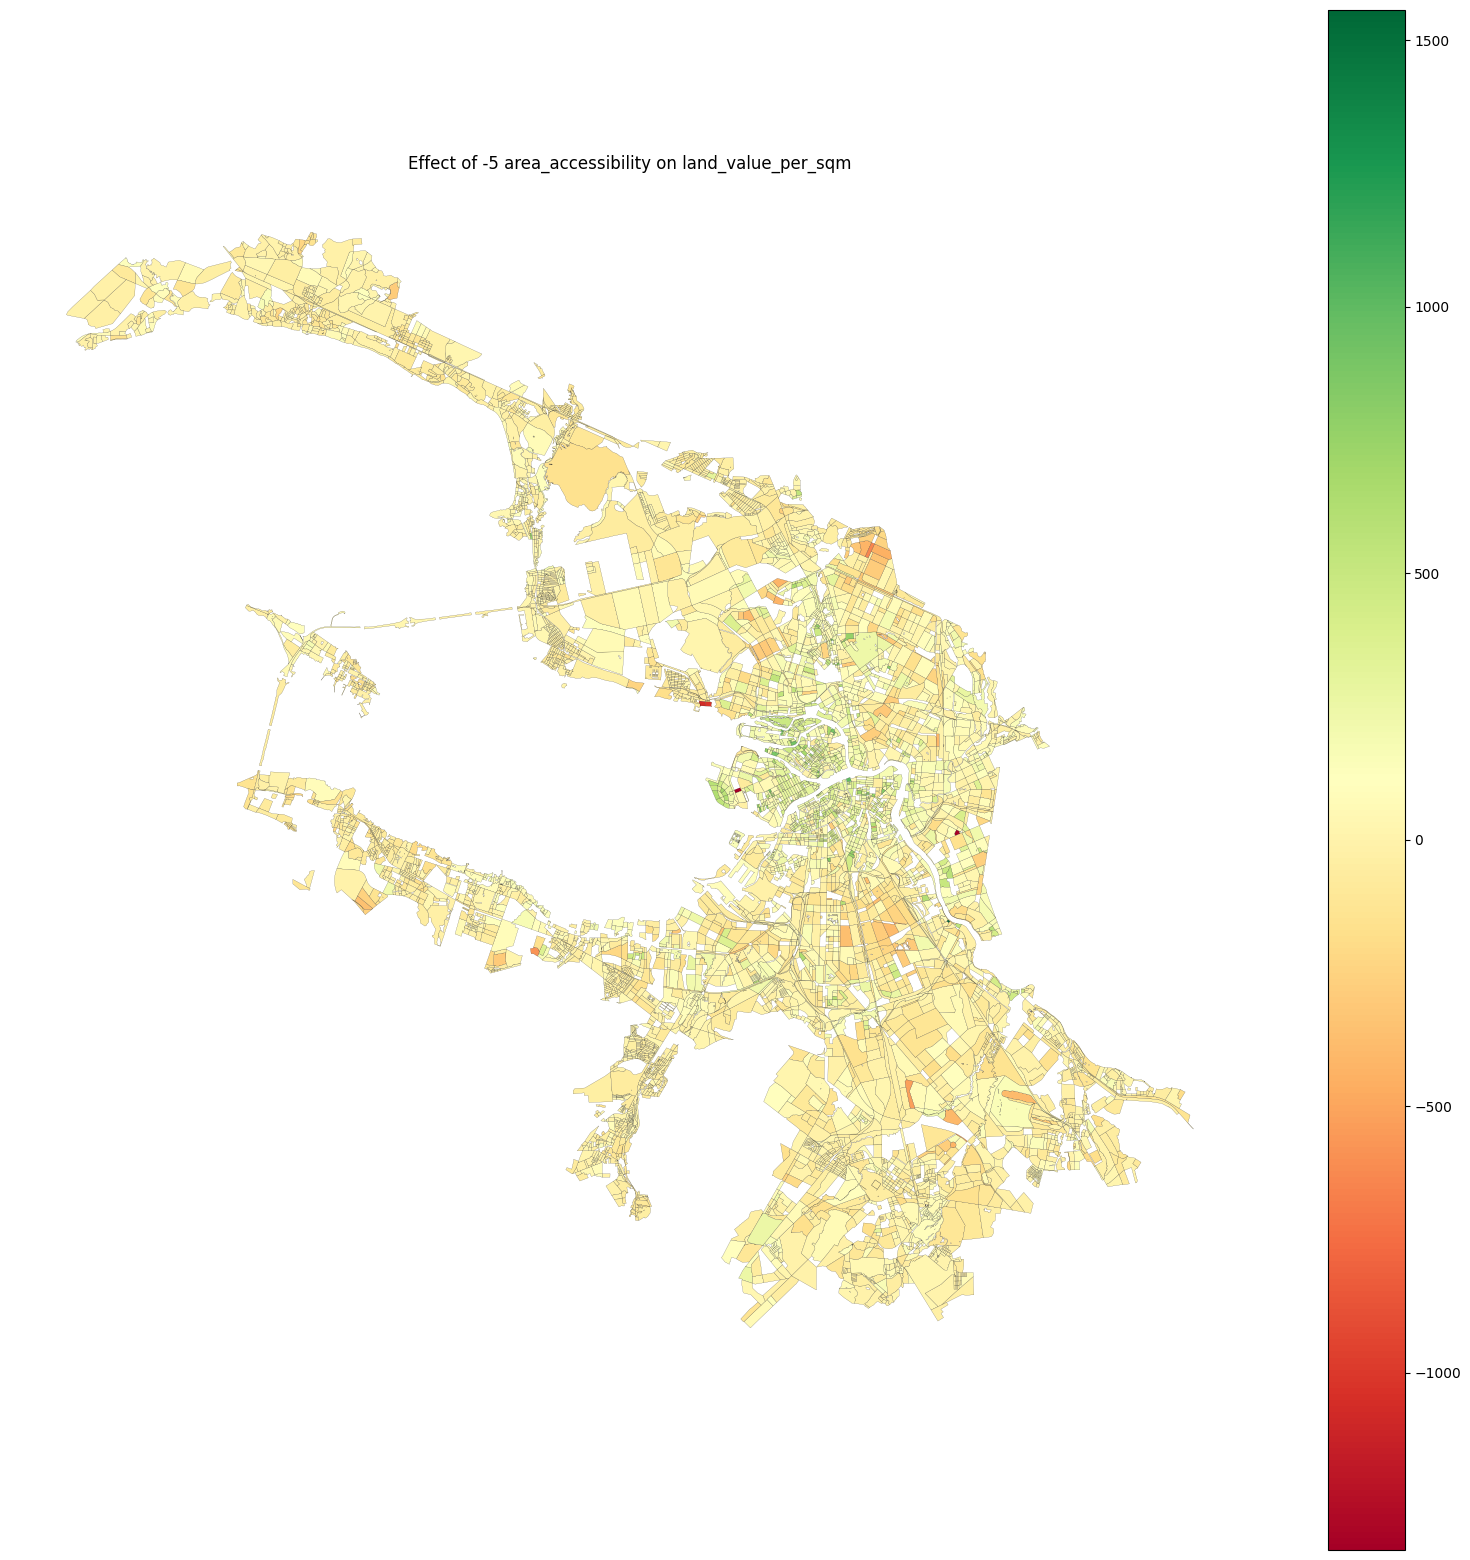

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20, 20))

result.plot(
    column="treatment_effect_per_unit",
    cmap="RdYlGn",
    legend=True,
    ax=ax,
    edgecolor="black",
    linewidth=0.1,
)

ax.set_title("Effect of -5 area_accessibility on land_value_per_sqm")
ax.axis("off")
plt.show()


In [13]:
# === Simple train/test training (без фолдов) ===
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.metrics import r2_score
import numpy as np
from catboost import CatBoostRegressor, Pool
from urbanomy.methods.land_value_modeling.training_utils import (
    build_radii_weights,
    add_lags_full_df,
    feature_names,
    to_original_scale,
    mape,
    wape,
)

# 1) Настройки
target_col = "land_value_per_sqm"   # как в твоем ноутбуке
radius_list = [300, 500, 1000, 2000, 3000]
test_size = 0.2
seed = 42
use_services = False

exclude_base = {
    "geometry",
    "land_value",
    "land_value_per_sqm",
    "log_land_value_per_sqm",
    "log_land_value",
    "osr",
    "share_non_living",
    "share_living",
    # 'land_value_class_soft_0',
    # 'land_value_class_soft_1',
    # 'land_value_class_soft_2',
    # 'land_value_class_soft_3',
    # 'land_value_class_soft_4',
    # 'land_value_class_pred',
    "land_value_class_soft_expected",
}
cat_features = [c for c in ["land_use", "morphotype", ] if c in blocks_clean.columns]

def is_service_col(col: str) -> bool:
    return col.lower().startswith("count_")

# 2) Базовые признаки
feature_cols = []
for c in blocks_clean.columns:
    if c in exclude_base:
        continue
    if (not use_services) and is_service_col(c):
        continue
    feature_cols.append(c)

# 3) Подготовка данных + lag-фичи на всем датасете
data_df = blocks_clean.copy()


for c in cat_features:
    data_df[c] = data_df[c].astype("string").fillna("missing")

numeric_feats = [c for c in feature_cols if c not in cat_features and c != target_col and c in data_df.columns]

weights = build_radii_weights(data_df, radius_list)
data_lag = add_lags_full_df(data_df, weights=weights, numeric_cols=numeric_feats)

base_cols_for_model = list(dict.fromkeys([c for c in feature_cols if c in data_lag.columns] + cat_features))
feats = feature_names(data_lag, base_cols_for_model, target_col)

# 4) Один train/test split (без кросс-валидации)
idx_train, idx_test = train_test_split(
    data_lag.index,
    test_size=test_size,
    random_state=seed,
    shuffle=True,
)

df_train = data_lag.loc[idx_train].copy()
df_test = data_lag.loc[idx_test].copy()

train_pool = Pool(df_train[feats], label=df_train[target_col], cat_features=cat_features, feature_names=feats)
test_pool = Pool(df_test[feats], label=df_test[target_col], cat_features=cat_features, feature_names=feats)

# 5) Обучение
model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=20000,
    od_type="Iter",
    od_wait=500,
    random_seed=seed,
    verbose=200,
)

model.fit(
    train_pool,
    eval_set=test_pool,
    early_stopping_rounds=600,
    use_best_model=True,
)

# 6) Метрики на train и test в оригинальной шкале
# --- Train ---
y_train_pred_raw = np.asarray(model.predict(df_train[feats])).reshape(-1)
y_train_true_raw = df_train[target_col].to_numpy()

y_train_true = to_original_scale(y_train_true_raw, target_col=target_col)
y_train_pred = to_original_scale(y_train_pred_raw, target_col=target_col)

train_mape = mape(y_train_true, y_train_pred)
train_wape = wape(y_train_true, y_train_pred)
train_r2 = r2_score(y_train_true, y_train_pred)
train_mae = mean_absolute_error(y_train_true, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))

# --- Test ---
y_test_pred_raw = np.asarray(model.predict(df_test[feats])).reshape(-1)
y_test_true_raw = df_test[target_col].to_numpy()

y_test_true = to_original_scale(y_test_true_raw, target_col=target_col)
y_test_pred = to_original_scale(y_test_pred_raw, target_col=target_col)

test_mape = mape(y_test_true, y_test_pred)
test_wape = wape(y_test_true, y_test_pred)
test_r2 = r2_score(y_test_true, y_test_pred)
test_mae = mean_absolute_error(y_test_true, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))

print("Train metrics:")
print(f"MAPE: {train_mape:.6f} ({train_mape*100:.2f}%)")
print(f"WAPE: {train_wape:.6f} ({train_wape*100:.2f}%)")
print(f"MAE:  {train_mae:.6f}")
print(f"RMSE: {train_rmse:.6f}")
print(f"R2:   {train_r2:.6f}")

print("\nTest metrics:")
print(f"MAPE: {test_mape:.6f} ({test_mape*100:.2f}%)")
print(f"WAPE: {test_wape:.6f} ({test_wape*100:.2f}%)")
print(f"MAE:  {test_mae:.6f}")
print(f"RMSE: {test_rmse:.6f}")
print(f"R2:   {test_r2:.6f}")


Learning rate set to 0.010737
0:	learn: 5659.5862943	test: 5930.2851382	best: 5930.2851382 (0)	total: 63.7ms	remaining: 21m 14s
200:	learn: 3065.1732459	test: 3331.5914134	best: 3331.5914134 (200)	total: 1.35s	remaining: 2m 12s
400:	learn: 2646.1323285	test: 3003.7513104	best: 3003.5850666 (399)	total: 2.66s	remaining: 2m 10s
600:	learn: 2435.3344166	test: 2900.1843357	best: 2900.1843357 (600)	total: 3.9s	remaining: 2m 5s
800:	learn: 2262.2151557	test: 2850.9267968	best: 2850.9267968 (800)	total: 5.25s	remaining: 2m 5s
1000:	learn: 2104.2129952	test: 2810.2167074	best: 2810.2167074 (1000)	total: 6.49s	remaining: 2m 3s
1200:	learn: 1964.6045930	test: 2775.0978388	best: 2774.8170711 (1193)	total: 7.9s	remaining: 2m 3s
1400:	learn: 1845.7932780	test: 2752.0314604	best: 2751.7072119 (1397)	total: 9.12s	remaining: 2m 1s
1600:	learn: 1736.3564428	test: 2734.7813817	best: 2734.7813817 (1600)	total: 10.3s	remaining: 1m 58s
1800:	learn: 1642.5029289	test: 2718.5074766	best: 2718.2199260 (1793)	

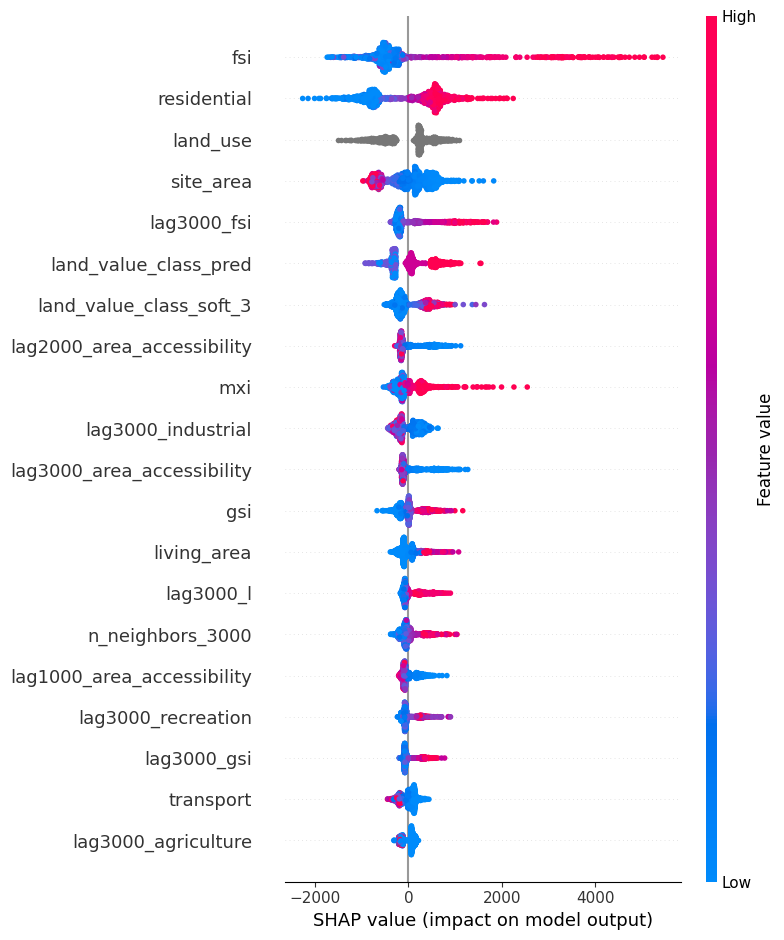

In [13]:
# === SHAP через shap: только 2 графика (beeswarm + bar) ===
import shap

X_test = df_test[feats]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 1) Beeswarm
shap.summary_plot(shap_values, X_test, feature_names=feats, show=True)





In [14]:
numeric_feats

['residential',
 'business',
 'recreation',
 'industrial',
 'transport',
 'special',
 'agriculture',
 'share',
 'footprint_area',
 'build_floor_area',
 'living_area',
 'non_living_area',
 'population',
 'site_area',
 'fsi',
 'gsi',
 'mxi',
 'l',
 'area_accessibility',
 'land_value_class_soft_0',
 'land_value_class_soft_1',
 'land_value_class_soft_2',
 'land_value_class_soft_3',
 'land_value_class_pred']

In [15]:
# === Inference + метрики для land_value_per_sqm ===
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score

from urbanomy.methods.land_value_modeling.training_utils import (
    prep_cat_inplace,
    build_radii_weights,
    add_lags_full_df,
)

# target теперь зафиксирован
target_col = "land_value_per_sqm"

# 1) Построить lag-фичи тем же способом, что на обучении
work_df = blocks_clean.copy()
prep_cat_inplace(work_df, cat_features)

weights_inf = build_radii_weights(work_df, radius_list)
data_lag_inf = add_lags_full_df(work_df, weights=weights_inf, numeric_cols=numeric_feats)

# 2) Проверка фичей
missing_feats = [c for c in feats if c not in data_lag_inf.columns]
if missing_feats:
    raise ValueError(
        f"Не хватает фичей для модели ({len(missing_feats)}): "
        f"{missing_feats[:20]}{' ...' if len(missing_feats) > 20 else ''}"
    )

# 3) Предсказание (raw -> original scale)
y_pred_raw = np.asarray(model.predict(data_lag_inf[feats])).reshape(-1)
y_pred = to_original_scale(y_pred_raw, target_col=target_col)

out_df = data_lag_inf.copy()
out_df["pred_raw"] = y_pred_raw
out_df["land_value_per_sqm_pred"] = y_pred

# 4) Метрики и error_pct
if target_col in out_df.columns:
    y_true_raw = out_df[target_col].to_numpy()
    y_true = to_original_scale(y_true_raw, target_col=target_col)

    out_df["land_value_per_sqm_true"] = y_true

    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (np.abs(y_true) > 0)
    out_df["error_pct"] = np.nan
    out_df.loc[mask, "error_pct"] = (
        np.abs(y_pred[mask] - y_true[mask]) / np.abs(y_true[mask]) * 100.0
    )

    mape_val = mape(y_true[mask], y_pred[mask])   # доля
    wape_val = wape(y_true[mask], y_pred[mask])   # доля
    r2_val = r2_score(y_true[mask], y_pred[mask])

    print(f"Rows used in metrics: {mask.sum()} / {len(mask)}")
    print(f"MAPE: {mape_val:.6f} ({mape_val*100:.2f}%)")
    print(f"WAPE: {wape_val:.6f} ({wape_val*100:.2f}%)")
    print(f"R2:   {r2_val:.6f}")

    display(out_df[[target_col, "land_value_per_sqm_pred", "error_pct"]].head(20))

    out_df_over_10 = out_df[out_df["error_pct"] > 10].copy()
else:
    print(f"Column '{target_col}' not found -> predictions only.")
    display(out_df[["land_value_per_sqm_pred"]].head(20))


Rows used in metrics: 7017 / 7017
MAPE: 0.234389 (23.44%)
WAPE: 0.148283 (14.83%)
R2:   0.940800


,land_value_per_sqm,land_value_per_sqm_pred,error_pct
0,942.386203,1319.518770,40.018897
1,1952.414484,2292.178545,17.402251
2,1507.223306,1444.272588,4.176602
3,2197.747147,3028.267946,37.789643
4,8603.688296,8029.453218,6.674290
5,1421.128598,1013.854117,28.658524
8,1160.558788,1561.976564,34.588319
9,3325.537139,3502.533562,5.322341
10,1627.563780,2163.244301,32.913028
11,631.882251,609.648475,3.518658


In [16]:
out_df_over_10 = out_df[out_df["error_pct"] > 100]
out_df_20 = out_df[out_df["error_pct"] <= 100]


In [17]:
stats_by_landuse = (
    out_df_20
    .groupby("land_use", dropna=False)
    .agg(
        n=("error_pct", "size"),
        mean_error_pct=("error_pct", "mean"),
        median_error_pct=("error_pct", "median"),
        p90_error_pct=("error_pct", lambda s: s.quantile(0.90)),
        max_error_pct=("error_pct", "max"),
    )
    .sort_values("mean_error_pct", ascending=False)
)

display(stats_by_landuse)

,n,mean_error_pct,median_error_pct,p90_error_pct,max_error_pct
land_use,,,,,
AGRICULTURE,108,31.791754,27.895589,63.298234,93.311029
RECREATION,968,25.020832,19.634253,55.094467,99.338722
TRANSPORT,780,24.425215,19.402619,51.899764,98.353493
SPECIAL,97,23.824035,14.353578,58.154841,98.022215
BUSINESS,264,21.344969,13.359414,52.165925,99.740838
INDUSTRIAL,442,20.505000,15.417784,44.656966,99.376791
RESIDENTIAL,4149,16.055891,10.777574,37.316170,99.929949


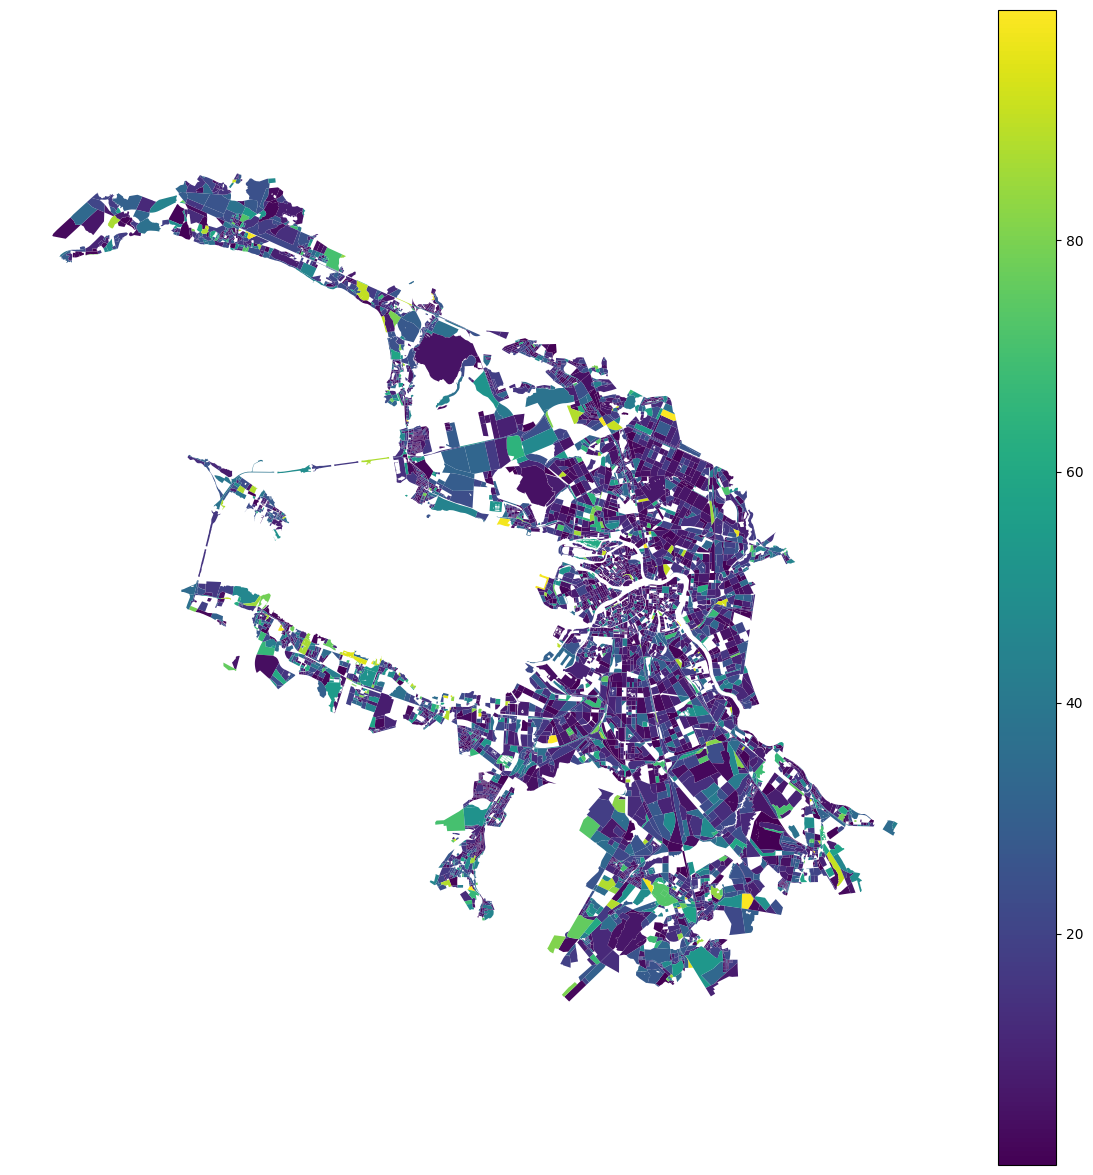

In [18]:
out_df_20.plot(
    column='error_pct',
    legend=True,
    figsize=(15,15),
    cmap='viridis'
).set_axis_off()

In [19]:
stats_by_landuse = (
    out_df_over_10
    .groupby("land_use", dropna=False)
    .agg(
        n=("error_pct", "size"),
        mean_error_pct=("error_pct", "mean"),
        median_error_pct=("error_pct", "median"),
        p90_error_pct=("error_pct", lambda s: s.quantile(0.90)),
        max_error_pct=("error_pct", "max"),
    )
    .sort_values("mean_error_pct", ascending=False)
)

display(stats_by_landuse)

,n,mean_error_pct,median_error_pct,p90_error_pct,max_error_pct
land_use,,,,,
INDUSTRIAL,5,198.951723,190.580836,313.470660,366.885961
BUSINESS,6,197.722250,132.210311,346.833505,531.381492
RECREATION,97,182.719280,132.344451,310.324067,1062.068023
TRANSPORT,27,156.991496,134.675474,190.254966,419.205967
RESIDENTIAL,58,136.713284,120.111983,185.621428,342.680555
AGRICULTURE,11,133.245070,128.764756,164.837045,199.590668
SPECIAL,5,120.375162,115.611903,142.031529,148.439532


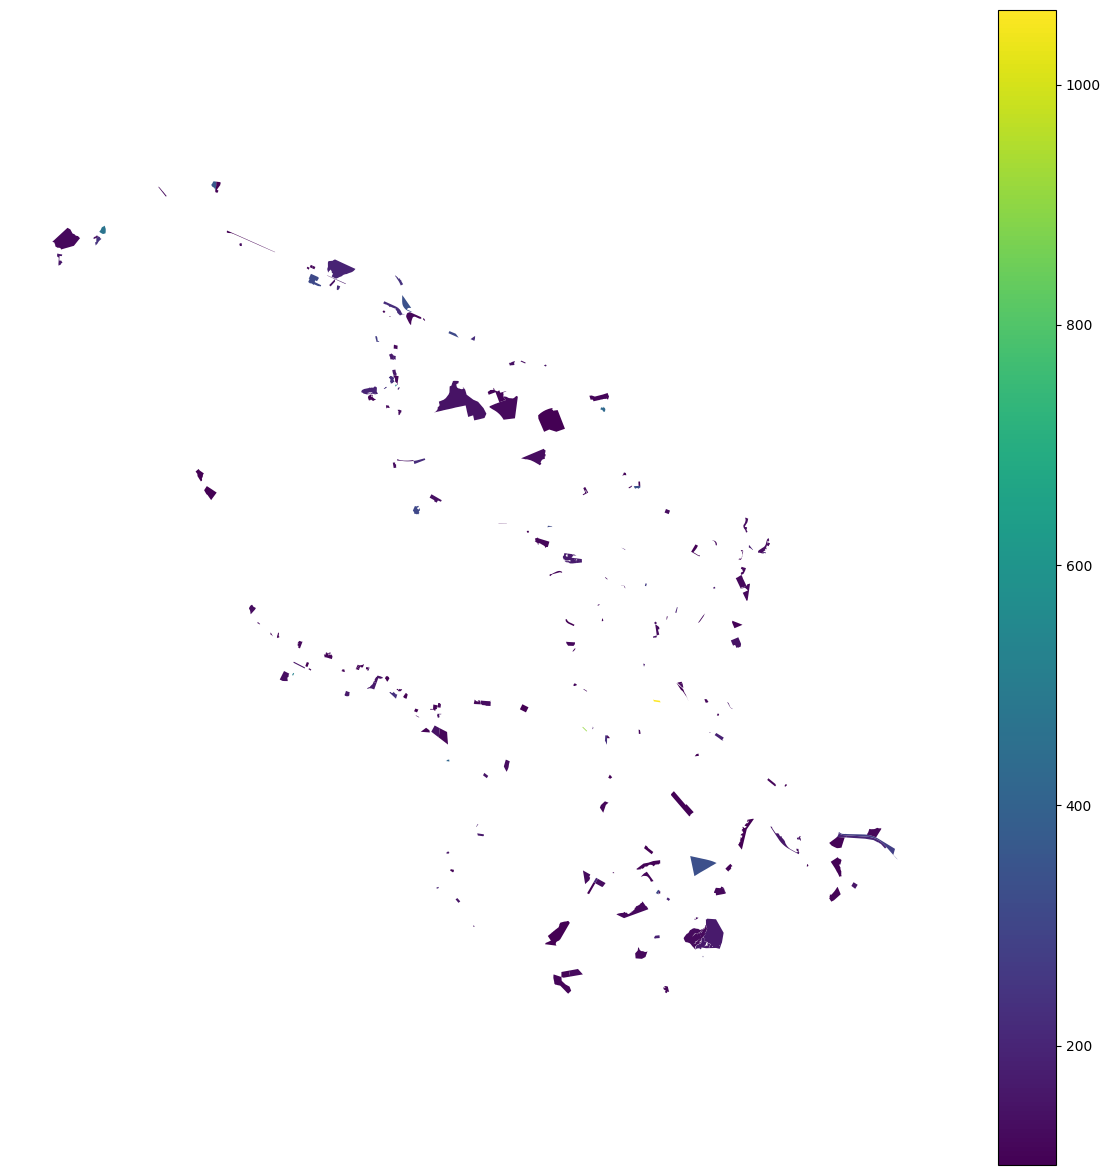

In [20]:
out_df_over_10.plot(
    column='error_pct',
    legend=True,
    figsize=(15,15),
    cmap='viridis'
).set_axis_off()

In [21]:
# === Conformal interval по land_use ===
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

alpha = 0.10  # 90% PI
group_col = "land_use"
true_col = "land_value_per_sqm_true"
pred_col = "land_value_per_sqm_pred"

# 1) валидные строки
valid_mask = (
    np.isfinite(out_df[true_col].to_numpy()) &
    np.isfinite(out_df[pred_col].to_numpy()) &
    out_df[group_col].notna()
)
df_valid = out_df.loc[valid_mask].copy()

# 2) calibration / evaluation
idx_cal, idx_eval = train_test_split(
    df_valid.index, test_size=0.5, random_state=42, shuffle=True
)
cal_df = df_valid.loc[idx_cal].copy()
eval_df = df_valid.loc[idx_eval].copy()

# 3) глобальный q_hat (fallback)
abs_err_cal_all = np.abs(cal_df[pred_col] - cal_df[true_col]).to_numpy()
n_all = len(abs_err_cal_all)
k_all = int(np.ceil((n_all + 1) * (1 - alpha)))
k_all = min(max(k_all, 1), n_all)
q_hat_global = np.partition(abs_err_cal_all, k_all - 1)[k_all - 1]

# 4) q_hat по группам land_use
min_cal_size = 30  # если в группе мало точек, используем глобальный q_hat
qhat_by_group = {}

for g, gdf in cal_df.groupby(group_col):
    abs_err = np.abs(gdf[pred_col] - gdf[true_col]).to_numpy()
    n = len(abs_err)
    if n < min_cal_size:
        qhat_by_group[g] = q_hat_global
        continue
    k = int(np.ceil((n + 1) * (1 - alpha)))
    k = min(max(k, 1), n)
    qhat_by_group[g] = np.partition(abs_err, k - 1)[k - 1]

# 5) строим интервалы
q_series = out_df[group_col].map(qhat_by_group).fillna(q_hat_global)
out_df["q_hat_land_use"] = q_series

out_df["pi_lower"] = (out_df[pred_col] - out_df["q_hat_land_use"]).clip(lower=0)
out_df["pi_upper"] = out_df[pred_col] + out_df["q_hat_land_use"]

# 6) оценка покрытия на eval
eval_tmp = out_df.loc[idx_eval].copy()
covered_eval = (eval_tmp[true_col] >= eval_tmp["pi_lower"]) & (eval_tmp[true_col] <= eval_tmp["pi_upper"])

coverage_eval_total = covered_eval.mean() * 100
avg_width_eval_total = (eval_tmp["pi_upper"] - eval_tmp["pi_lower"]).mean()

print(f"Target coverage: {(1-alpha)*100:.1f}%")
print(f"Empirical coverage (eval, total): {coverage_eval_total:.2f}%")
print(f"Average interval width (eval, total): {avg_width_eval_total:.2f}")

# покрытие по land_use
coverage_by_landuse = (
    eval_tmp.assign(covered=covered_eval)
    .groupby(group_col)
    .agg(
        n=("covered", "size"),
        coverage_pct=("covered", lambda s: s.mean() * 100),
        avg_width=("pi_upper", lambda s: (s - eval_tmp.loc[s.index, "pi_lower"]).mean()),
        q_hat=("q_hat_land_use", "mean"),
    )
    .sort_values("coverage_pct")
)

display(coverage_by_landuse)
display(out_df[[group_col, true_col, pred_col, "pi_lower", "pi_upper", "q_hat_land_use"]].head(20))


Target coverage: 90.0%
Empirical coverage (eval, total): 80.22%
Average interval width (eval, total): 2569.33


,n,coverage_pct,avg_width,q_hat
land_use,,,,
BUSINESS,136,75.735294,2404.821114,1228.702621
RESIDENTIAL,2113,78.987222,3003.525093,1502.744918
INDUSTRIAL,231,79.653680,1798.786717,901.112224
SPECIAL,44,81.818182,1462.307183,740.949588
RECREATION,515,81.941748,2126.268515,1075.240421
AGRICULTURE,59,84.745763,965.926271,496.530204
TRANSPORT,411,85.401460,1728.417185,877.884469


,land_use,land_value_per_sqm_true,land_value_per_sqm_pred,pi_lower,pi_upper,q_hat_land_use
0,AGRICULTURE,942.386203,1319.518770,822.988566,1816.048974,496.530204
1,RESIDENTIAL,1952.414484,2292.178545,789.433627,3794.923462,1502.744918
2,RESIDENTIAL,1507.223306,1444.272588,0.000000,2947.017506,1502.744918
3,RESIDENTIAL,2197.747147,3028.267946,1525.523028,4531.012863,1502.744918
4,INDUSTRIAL,8603.688296,8029.453218,7128.340995,8930.565442,901.112224
5,AGRICULTURE,1421.128598,1013.854117,517.323913,1510.384321,496.530204
8,RESIDENTIAL,1160.558788,1561.976564,59.231647,3064.721482,1502.744918
9,RESIDENTIAL,3325.537139,3502.533562,1999.788645,5005.278480,1502.744918
10,RESIDENTIAL,1627.563780,2163.244301,660.499383,3665.989218,1502.744918
11,AGRICULTURE,631.882251,609.648475,113.118271,1106.178679,496.530204


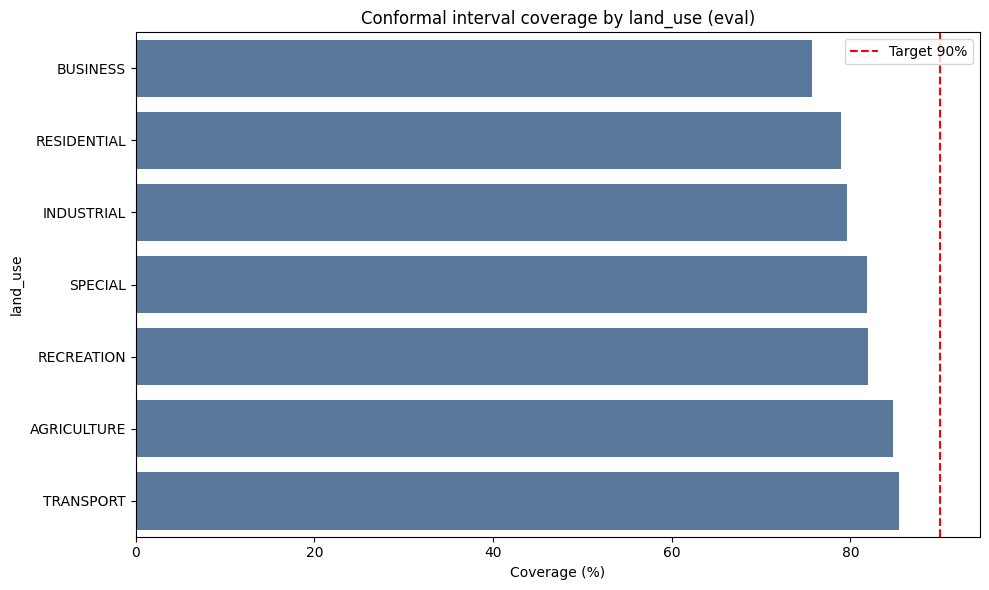

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

target_cov = (1 - alpha) * 100  # например 90%

plot_df = coverage_by_landuse.reset_index().copy()
plot_df = plot_df.sort_values("coverage_pct", ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="coverage_pct", y=group_col, color="#4C78A8")
plt.axvline(target_cov, color="red", linestyle="--", label=f"Target {target_cov:.0f}%")
plt.xlabel("Coverage (%)")
plt.ylabel(group_col)
plt.title("Conformal interval coverage by land_use (eval)")
plt.legend()
plt.tight_layout()
plt.show()


In [23]:
# out_df_over_10.to_file("../data/blocks_with_error_over_100pct4.geojson", driver="GeoJSON")